# 02 — Figures 3 and 4: critical limit trends

These notebooks are meant to be run from the repository root. If you open one from the `examples/` folder, the first code cell below moves Python to the parent directory so local modules such as `cbp_stability.py` can be imported.

In [ ]:
from pathlib import Path
import os
if Path.cwd().name == 'examples':
    os.chdir('..')
print(Path.cwd())

Figures 3 and 4 summarize the critical semimajor-axis ratio over the full `a_crit.txt` grid. This notebook groups the grid by binary eccentricity, plots the median value over mass ratio, and overlays common fit curves.

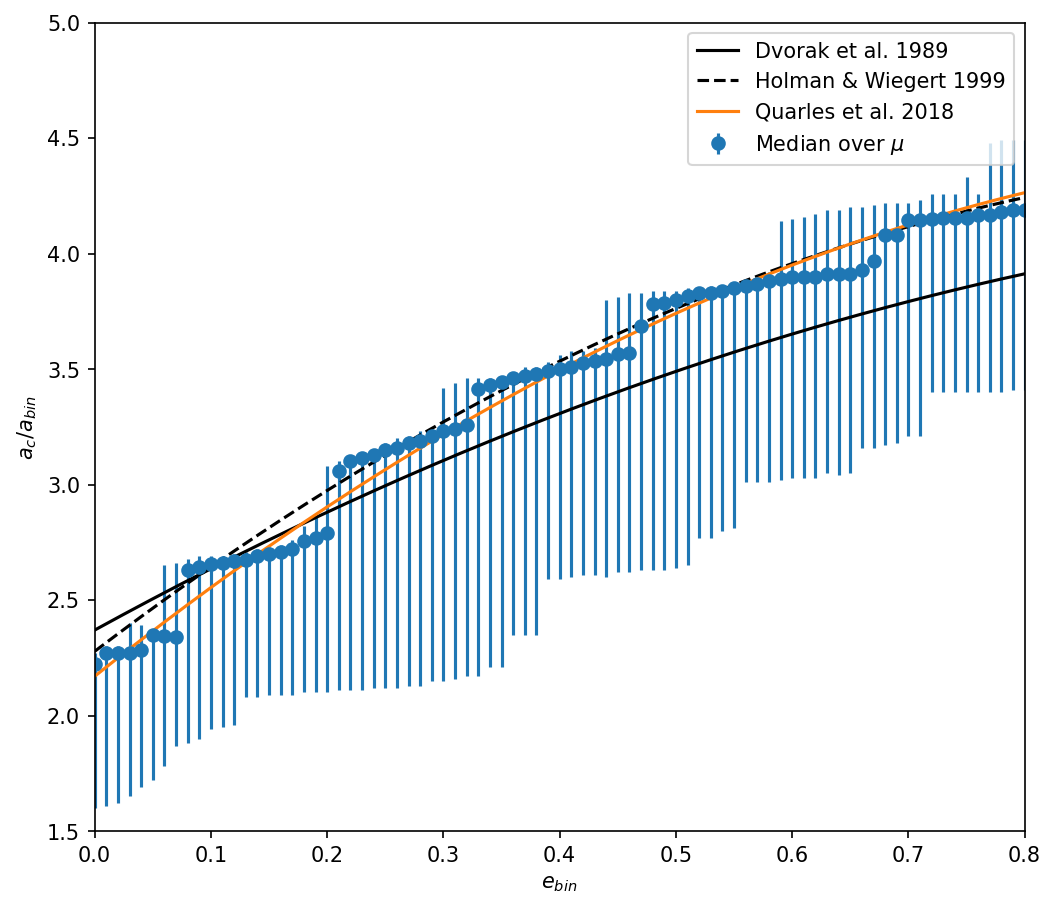

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from cbp_stability import load_acrit

data = load_acrit()
mu, eb, ac = data.T

e_values = np.array(sorted(set(eb)))
med, lo, hi = [], [], []
for e in e_values:
    vals = ac[np.isclose(eb, e) & (mu >= 0.01)]
    med.append(np.median(vals))
    lo.append(np.median(vals) - vals.min())
    hi.append(vals.max() - np.median(vals))
med = np.array(med)
yerr = np.vstack([lo, hi])

x = np.linspace(0, 0.8, 200)
dvorak = 2.37 + 2.76*x - 1.04*x**2
hw99 = 2.278 + 3.824*x - 1.71*x**2
q2018 = 2.170 + 4.017*x - 1.75*x**2

fig, ax = plt.subplots(figsize=(8, 7), dpi=150)
ax.errorbar(e_values, med, yerr=yerr, fmt='o', label='Median over $\mu$')
ax.plot(x, dvorak, 'k-', label='Dvorak et al. 1989')
ax.plot(x, hw99, 'k--', label='Holman & Wiegert 1999')
ax.plot(x, q2018, '-', label='Quarles et al. 2018')
ax.set_xlabel(r'$e_{bin}$')
ax.set_ylabel(r'$a_c/a_{bin}$')
ax.set_xlim(0, 0.8)
ax.set_ylim(1.5, 5)
ax.legend()
plt.show()